# **Bab 01 Pengantar Sains Data dari Buku Prinsip Sains Data.**

### Eksplorasi Data Awal dengan Pandas

Langkah pertama dalam analisis data adalah melakukan eksplorasi awal untuk memahami struktur, konten, dan karakteristik dasar dari dataset. Ini meliputi:

1.  **Membaca Data:** Mengimpor dataset ke dalam DataFrame Pandas.
2.  **Melihat Dimensi Dataset:** Memeriksa jumlah baris dan kolom untuk mendapatkan gambaran ukuran data.
3.  **Melihat Lima Baris Pertama:** Menampilkan beberapa baris pertama data untuk melihat sekilas format dan isinya.
4.  **Memeriksa Tipe Data:** Memahami tipe data setiap kolom (misalnya, numerik, objek/string, datetime) untuk mengidentifikasi kebutuhan konversi atau pembersihan data.
5.  **Statistik Deskriptif:** Menghitung statistik ringkasan seperti mean, median, min, max, dan standar deviasi untuk kolom numerik guna memahami distribusi data dan mendeteksi anomali.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data dari URL langsung
url = "https://raw.githubusercontent.com/wmaharani/prinsip-sains-data/main/data/e-commerce_data.csv"
df = pd.read_csv(url, encoding='latin1')

# Gambaran umum dataset
print("=== Dimensi Dataset ===")
print(f"Baris   : {df.shape[0]}")
print(f"Kolom   : {df.shape[1]}")

print("\n=== Lima Baris Pertama ===")
print(df.head())

print("\n=== Tipe Data ===")
print(df.dtypes)

print("\n=== Statistik Deskriptif ===")
print(df.describe())

=== Dimensi Dataset ===
Baris   : 232194
Kolom   : 8

=== Lima Baris Pertama ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

=== Tipe Data ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     objec

### Pemeriksaan Missing Values dan Konversi Tipe Data

Penting untuk mengidentifikasi dan menangani *missing values* karena dapat memengaruhi analisis dan model. Selain itu, beberapa kolom mungkin perlu dikonversi ke tipe data yang sesuai untuk analisis yang lebih akurat, seperti mengonversi tanggal dari string ke format datetime.

In [ ]:
# Memeriksa Missing Values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Mengonversi InvoiceDate ke tipe datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("\n=== Tipe Data Setelah Konversi InvoiceDate ===")
print(df.dtypes)


=== Missing Values ===
InvoiceNo          0
StockCode          0
Description      887
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     65192
Country            0
dtype: int64

=== Tipe Data Setelah Konversi InvoiceDate ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


### Analisis Data Kuantitatif dan Kualitatif

Setelah penanganan dasar, kita dapat mulai menganalisis distribusi dan karakteristik unik dari kolom-kolom kunci, seperti `Quantity`, `UnitPrice`, `CustomerID`, `Country`, dan membuat fitur baru dari `InvoiceDate`.

In [ ]:
# Memeriksa nilai unik di kolom Quantity dan UnitPrice (khususnya nilai negatif atau nol)
print("\n=== Nilai Unik Quantity Negatif ===")
print(df[df['Quantity'] < 0]['Quantity'].unique())

print("\n=== Nilai Unik UnitPrice Nol ===")
print(df[df['UnitPrice'] == 0]['UnitPrice'].unique())

# Memeriksa jumlah nilai unik di beberapa kolom kategorikal
print("\n=== Jumlah Nilai Unik per Kolom ===")
print(df[['InvoiceNo', 'StockCode', 'Description', 'Country']].nunique())


=== Nilai Unik Quantity Negatif ===
[    -1    -12    -24     -6     -2     -4     -5     -7     -3    -10
  -9360    -38    -36   -192   -144    -48    -50    -20    -22    -30
    -70   -130    -80   -120    -40    -25    -14    -15    -69   -140
   -320     -8     -9    -11    -72    -35    -21    -43    -19    -18
    -44    -77   -223   -150    -13    -33   -723   -177    -32   -100
    -28   -145    -47    -96    -60    -16   -240   -300   -500    -23
   -106    -54    -17   -939   -201    -53    -29  -2600   -990   -290
    -45   -310    -61    -41 -74215    -64    -84  -1400    -57    -59
    -31   -600    -42    -94   -207    -52   -206   -217  -1430   -162
   -230   -173   -390   -234    -76   -200    -99    -92   -741   -400
   -114    -88   -720    -86   -391    -87   -278   -154  -3000   -675
   -210   -345   -975  -1200  -1121    -27   -541  -1277   -197  -1100
    -63  -5368   -259    -82   -178   -110   -102   -323   -450   -232
    -83   -153   -524  -2472    -49   -1

In [ ]:
# Membuat fitur baru dari InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek # Monday=0, Sunday=6

# Menghitung TotalPrice (Quantity * UnitPrice)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("\n=== Lima Baris Pertama dengan Fitur Baru ===")
print(df.head())


=== Lima Baris Pertama dengan Fitur Baru ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Year  Month  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  2010     12   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  2010     12   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  2010     12   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  2010     12   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  2010     12   

   Day  Hour  DayOfWeek  TotalPrice  
0    1     8        

### Visualisasi Top 10 Negara Berdasarkan Total Penjualan

Untuk memahami pasar terbesar, kita akan memvisualisasikan 10 negara dengan total penjualan tertinggi. Ini akan memberikan gambaran cepat tentang kontributor utama pendapatan.

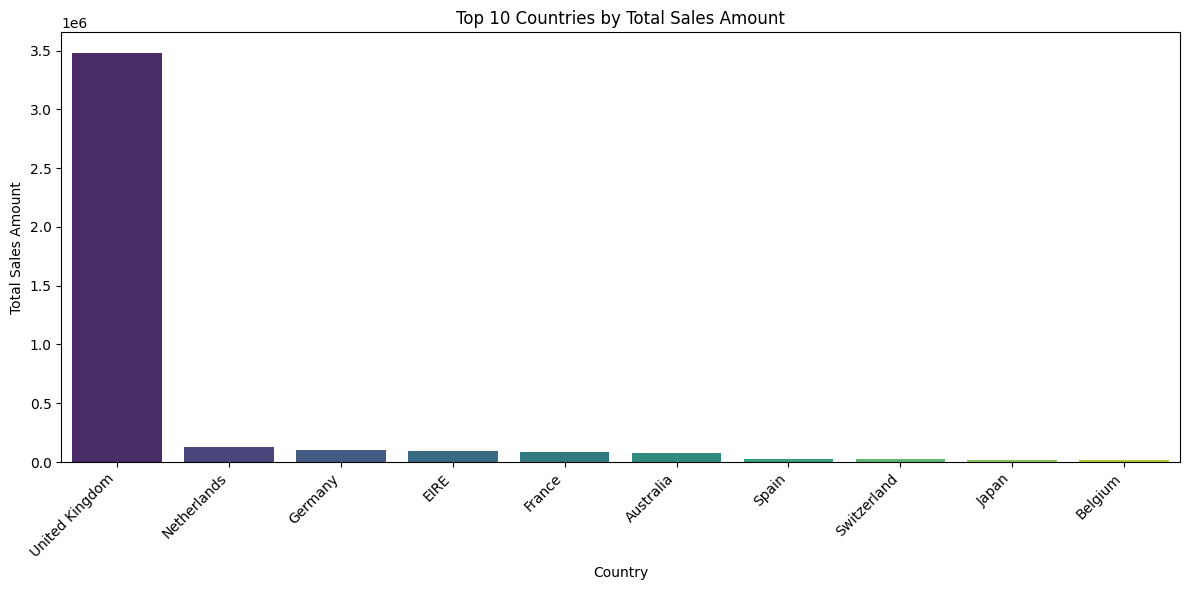

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung total penjualan per negara
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# Ambil 10 negara teratas
top_10_countries = country_sales.head(10)

# Buat bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Country', y='TotalPrice', data=top_10_countries, palette='viridis', hue='Country', legend=False)
plt.title('Top 10 Countries by Total Sales Amount')
plt.xlabel('Country')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Identifikasi Top 5 Produk Berdasarkan Total Penjualan

Untuk memahami produk mana yang paling berkontribusi pada pendapatan, kita akan mengidentifikasi 5 produk teratas berdasarkan total nilai penjualan.

In [ ]:
# Hitung total penjualan per produk
product_sales = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# Ambil 5 produk teratas
top_5_products = product_sales.head(5)

print("\n=== Top 5 Products by Total Sales Amount ===")
display(top_5_products)


=== Top 5 Products by Total Sales Amount ===


,Description,TotalPrice
0,REGENCY CAKESTAND 3 TIER,99648.69
1,DOTCOM POSTAGE,85481.57
2,WHITE HANGING HEART T-LIGHT HOLDER,55572.38
3,PARTY BUNTING,54409.24
4,JUMBO BAG RED RETROSPOT,40700.47


/tmp/ipykernel_1053/3744394606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Description', y='TotalPrice', data=top_5_products, palette='viridis')


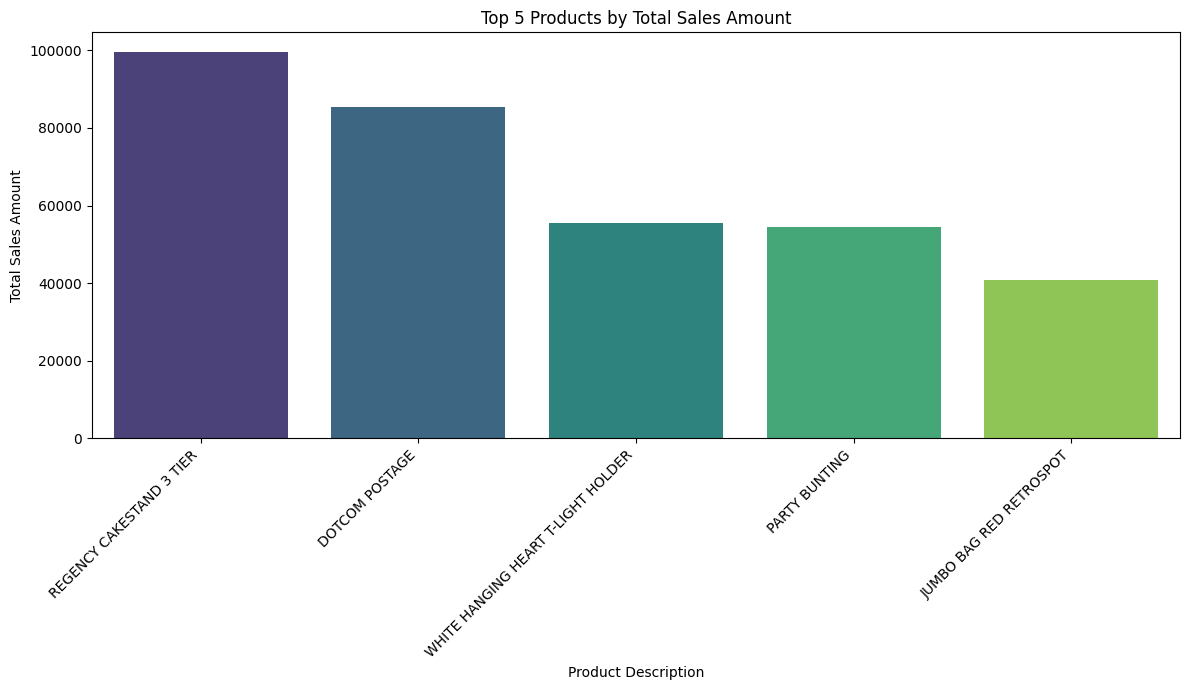

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Description', y='TotalPrice', data=top_5_products, palette='viridis')
plt.title('Top 5 Products by Total Sales Amount')
plt.xlabel('Product Description')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

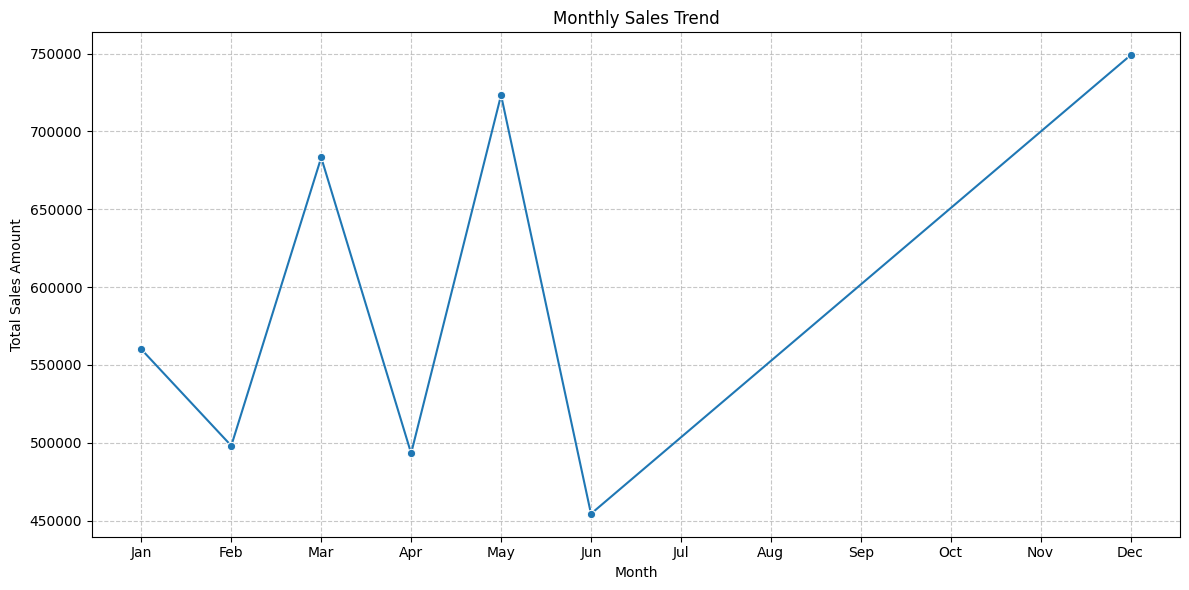

In [ ]:
# Calculate total sales per month
monthly_sales = df.groupby('Month')['TotalPrice'].sum().reset_index()

# Create a line plot for monthly sales trends
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='TotalPrice', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()